# 01 — Exploratory Data Analysis: Credit Card Fraud

**Goal of this notebook:** form concrete recommendations for Phase 3 (model training) by answering four questions:

1. How extreme is the class imbalance? → choice of metrics
2. What is the structure of features `V1`–`V28`? → limits on feature engineering
3. Is `Amount` skewed enough to need scaling? → standardization
4. Which features carry the most fraud signal? → sanity check

**Dataset:** 284,807 European credit card transactions from Sept 2013 (Worldline/ULB), mirrored on OpenML id=1597. Features `V1`–`V28` are PCA components of the original (private) features; `Amount` is raw. The Kaggle original includes a `Time` column; this OpenML mirror does not.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "creditcard.parquet"
df = pd.read_parquet(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (284807, 30)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Class imbalance

The first thing every fraud-detection EDA must quantify. The ratio determines our entire evaluation strategy.

Counts:
Class
0    284315
1       492

Percentages:
Class
0    99.8273
1     0.1727

Imbalance ratio (legit : fraud) = 578 : 1
Trivial 'always predict 0' accuracy = 99.83%


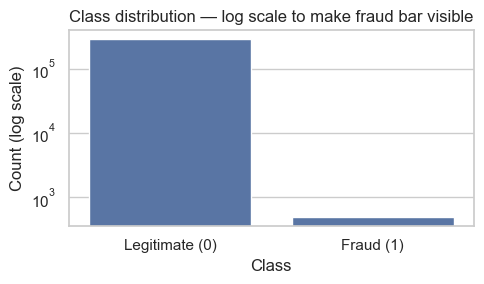

In [2]:
class_counts = df["Class"].value_counts().sort_index()
class_pct = 100 * class_counts / len(df)
imbalance_ratio = class_counts[0] / class_counts[1]

print("Counts:")
print(class_counts.to_string())
print("\nPercentages:")
print(class_pct.round(4).to_string())
print(f"\nImbalance ratio (legit : fraud) = {imbalance_ratio:.0f} : 1")
print(f"Trivial 'always predict 0' accuracy = {class_pct[0]:.2f}%")

fig, ax = plt.subplots(1, 1, figsize=(5, 3))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax)
ax.set_yscale("log")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Legitimate (0)", "Fraud (1)"])
ax.set_ylabel("Count (log scale)")
ax.set_title("Class distribution — log scale to make fraud bar visible")
plt.tight_layout()

**Takeaway 1:** ~577:1 imbalance. A model that always predicts 0 scores 99.83% accuracy and detects no fraud. Conclusion for Phase 3:

- **Do not use accuracy as the headline metric.**
- **Use Precision, Recall, F1, and especially AUPRC** (Area Under Precision-Recall Curve). AUPRC is more informative than ROC-AUC under extreme imbalance because the negative class dominates the false-positive rate denominator.
- Plan for **class weighting** or **resampling (SMOTE)** during training.

## 2. The PCA features (V1–V28)

These are the output of a PCA transformation applied by the data publishers to anonymize the original features (likely things like merchant category, card type, country, etc.). Two consequences:

1. We **cannot** do feature engineering on them (no domain meaning).
2. They are already approximately decorrelated (PCA does that). Tree-based models (which handle correlation poorly) and linear models (which can exploit decorrelated features) both should perform reasonably.

We do NOT need to scale V1–V28 — PCA outputs are already on comparable scales.

In [3]:
v_cols = [f"V{i}" for i in range(1, 29)]
df[v_cols].describe().T[["mean", "std", "min", "max"]].round(2)

,mean,std,min,max
V1,0.0,1.96,-56.41,2.45
V2,0.0,1.65,-72.72,22.06
V3,-0.0,1.52,-48.33,9.38
V4,0.0,1.42,-5.68,16.88
V5,0.0,1.38,-113.74,34.80
V6,0.0,1.33,-26.16,73.30
V7,-0.0,1.24,-43.56,120.59
V8,0.0,1.19,-73.22,20.01
V9,-0.0,1.10,-13.43,15.59
V10,0.0,1.09,-24.59,23.75


Means are near zero, standard deviations are O(1). Confirms the PCA-output story — already standardized, no further scaling needed for these 28 columns.

## 3. `Amount` — the only raw feature

> **Data-engineering note:** The original Kaggle dataset has a `Time` column (seconds since first transaction). The OpenML mirror (id=1597) drops it. Different mirrors of "the same" dataset can differ — always inspect before assuming. We work with what's actually here: `Amount` is the only un-anonymized numeric feature.

Amount (transaction value, EUR):
count    284807.00
mean         88.35
std         250.12
min           0.00
25%           5.60
50%          22.00
75%          77.16
max       25691.16


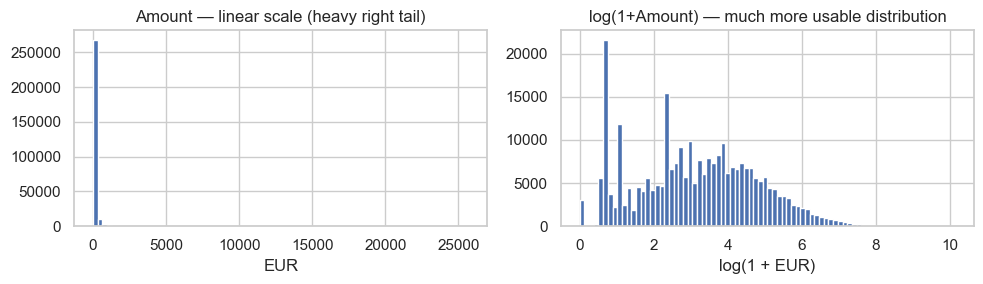

In [4]:
print("Amount (transaction value, EUR):")
print(df["Amount"].describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(df["Amount"], bins=80)
axes[0].set_title("Amount — linear scale (heavy right tail)")
axes[0].set_xlabel("EUR")
axes[1].hist(np.log1p(df["Amount"]), bins=80)
axes[1].set_title("log(1+Amount) — much more usable distribution")
axes[1].set_xlabel("log(1 + EUR)")
plt.tight_layout()

**Takeaway 3 (`Amount`):** extremely right-skewed (median ~22, max 25,691). Conclusions for preprocessing:

- Apply **`log1p`** then **StandardScaler**, OR use a Quantile/Robust scaler.
- Without scaling, linear models and neural networks weight Amount overwhelmingly.

## 4. Which features carry the most fraud signal?

Quick sanity check: for each feature, look at |correlation| with the target. Not a perfect proxy for feature importance (PCA components have non-linear relationships too) but a fast smell test for "is there signal at all."

Top 5 features by |correlation| with Class:
V17    0.326
V14    0.303
V12    0.261
V10    0.217
V16    0.197


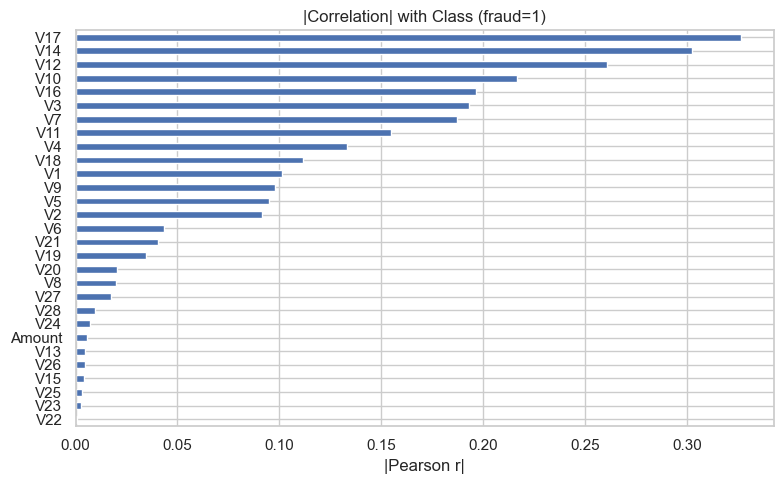

In [5]:
corrs = df.drop(columns=["Class"]).corrwith(df["Class"]).abs().sort_values(ascending=False)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
corrs.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("|Correlation| with Class (fraud=1)")
ax.set_xlabel("|Pearson r|")
plt.tight_layout()

print("Top 5 features by |correlation| with Class:")
print(corrs.head(5).round(3).to_string())

**Takeaway 4:** No feature has a huge linear correlation with fraud (top values around 0.3–0.4), which is expected after PCA. This tells us linear models alone will likely underperform — we'll want tree-based models (XGBoost, RandomForest) or non-linear models (MLP) that can exploit interactions. We will compare both families in Phase 3.

---
## Recommendations for Phase 3

| Decision | Choice | Why |
|---|---|---|
| Headline metric | AUPRC + F1 | Extreme imbalance makes accuracy & ROC-AUC misleading |
| Imbalance handling | Class weights AND/OR SMOTE | 577:1 ratio is too steep to ignore |
| Scale V1–V28 | No | Already PCA-standardized |
| Scale Amount | Yes — `log1p` + StandardScaler | Heavy right skew |
| Model families | Tree (XGBoost) + non-linear (MLP) | Linear won't capture interactions |
| Train/test split | Stratified | Preserve class ratio in both halves |